# Homework 1
##### Authors: Agata Mozwilo & Ólafur Fortune


##### Imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Exercise 6 (Virus test)
A medical company is assessing a newly developed
test for a certain virus. The so called false negative rate is small: if you have
contracted the virus, the probability that the test returns a positive result is
0.999. The false positive rate is also small: if you do not have the virus, the
probability that the test returns a positive result is only 0.005. Assume that 2%
of the population has contracted the virus. If a person chosen uniformly from the population is tested and the result comes back positive, what is the probability that the person has the virus?
### Answers:
* The probability of a randomly selected person having the virus given that their test is positive is $\approx 80.31 \% $


### Solution
The problem states that 

$$P(V)=0.02$$
$$P(+|V)=0.999$$
$$P(+|\overline{V})=0.005$$
Where V = A person has the virus and + means a person tests positive. 

We want to find $P(V|+)$, that is the probability of a randomly selected person having the virus given that their test is positive.

Bayes' theorem gives us:
$$P(V|+)=\frac{P(+|V)P(V)}{P(+)}$$
And we can find $P(+)$ using the law of total probability:
$$P(+)=P(+|V)P(V)+P(+|\overline{V})P(\overline{V})$$

Where
 $P(\overline{V})= 1 - 0.02=0.98$


Let us subsititue the values:

$$ P(+)=(0.999)(0.02)+(0.005)(0.98) = 0.01998 + 0.0049 = 0.02488$$

Therefore we get
$$P(V|+)=\frac{0.999(0.02)}{0.02488} = \frac{0.01998}{0.02488} \approx 0.8031 = 80.31\% $$


## Python
Draw $N=10^4$ pseudo random samples representing the infection status of N individuals. Use the samples and the statistics described above for the virus test to draw pseudo random samples representing a positive or negative virus test for each individual and verify your results from above.

In [2]:


N = 10000

#Infection status, 2% of the population has contracted the virus
infected = np.random.rand(N) < 0.02 

#Test results
positive = np.zeros(N, dtype=bool)

#Infected people: positive with probability 0.999
positive[infected] = np.random.rand(infected.sum()) < 0.999

#Not infected people: positive with probability 0.005
positive[~infected] = np.random.rand((~infected).sum()) < 0.005

#Estimate P(infected | positive)
estimate = infected[positive].mean()

print("Simulated P(infected | positive):", estimate)
print("Theoretical value:", 0.8030546624)





Simulated P(infected | positive): 0.8291666666666667
Theoretical value: 0.8030546624


## Exercise 16 (Group Testing)

### Answers: 
* The probability that the test for a pooled sample of $k$ people will be postive is $1-(1-p)^k$. The expected number of tests necessary is $\frac{n}{k}+n(1-(1-p)^k)$.

* The ideal value for $k$ minimises the expected number of tests. If $k$ is temporarily treated as a continous variable then we can minimise $E[\#\text{tests}]$ with respect to $k$ by setting $\frac{dE}{dk}=0$. We can then test the closest values that satisfy n/k being an integer to find the best integer $k$ value. Assuming $p$ is close to 0, the ideal $k$ for $p\in \{0.02,0.2,0.6\}$ are $k=[10,4,100]$, because pooling is no longer optimal for $p=0.6$.

* The small $p$ approximation says pooling is better for $p<\frac{1}{4}$. Simulation shows that pooling beats individual testing for $p\leq0.29$, and loses for larger $p$.


### Solution:
#### Probability for a pooled sample and expected number of tests:
The blood test can be viewed as a Bernoulli distribution, that is:
$$
Y=\begin{cases}
1  &\text{w.p }\:\: p \\
0 &\text{w.p }\:\: 1-p 
\end{cases}
$$
where $Y$ is the outcome of a singular test. If $X$ is defined as the number of successes (that is $X=Y_1+\cdots+Y_n$) then $X$ follows a binomial distribution $B(n,p)$ with parameters $n,p$:
$$
\mathbb{P}[X=j]=\begin{pmatrix}
n \\ j
\end{pmatrix}p^j(1-p)^{n-j}
$$
where $n$ is the number of trials and $j$ is the number of successes. In our case, the number of trials is $k$ and $j$ is the number of positive tests in a pool. If we let $X$ be the number of positive individuals in a pool of $k$ people then
$$
X∼B(k,p).
$$
The pooled test is positive if at least one person in the group tests positive, or in other words if $X\geq 1$. Since $j$ represents the number of positive individuals in the pool, only $j=1,2,\ldots,k$ are relevant for positive pooled tests, therefore:
$$
P(X\geq 1)=\sum_{j=1}^k\begin{pmatrix}
k \\ j
\end{pmatrix}p^j(1-p)^{k-j}.
$$
This can be rewritten as
$$
P(X\geq 1)=\sum_{j=0}^k\begin{pmatrix}
k \\ j
\end{pmatrix}p^j(1-p)^{k-j}-\begin{pmatrix}
k \\ 0
\end{pmatrix}p^0(1-p)^k.
$$
The first term is the total probability over all values of $X$, so it equals 1, therefore
$$
P(X\geq 1)=1-(1-p)^k
$$


If a pool is negative, then only 1 test is required, but if a pool is positive, then $k+1$ tests must be done. 

This means that the expected number of total tests necessary for a single pool is
$$
E[\#\text{tests per pool}]=1\cdot P(X=0)+(k+1)\cdot  P(X\geq 1).
$$
The value of $P(X=0)$ is equal to $1-P(X\geq1)$. Therefore,
$$
E[\#\text{tests per pool}]=(1-p)^k+(k+1)(1-(1-p)^k)
$$
$$
E[\#\text{tests per pool}]=1+k(1-(1-p)^k).
$$
With $\frac{n}{k}$ disjoint groups, the total number of tests necessary is
$$
E[\#\text{tests}]=\frac{n}{k}(1+k(1-(1-p)^k))=\frac{n}{k}+n(1-(1-p)^k)
$$

In [3]:
import numpy as np

n = 100
k = 10
p_values = [0.02, 0.2, 0.6]
runs = 10000

def run(n, k, p):
    results = np.random.binomial(1, p, n)

    groups = results.reshape(n // k, k)

    positive_pools = 0

    for group in groups:
        if np.sum(group) > 0:
            positive_pools += 1

    n_tests = n // k + k * positive_pools

    return n_tests, positive_pools


for p in p_values:
    total_tests = 0
    total_positive_pools = 0

    for i in range(runs):
        n_tests, positive_pools = run(n, k, p)

        total_tests += n_tests
        total_positive_pools += positive_pools

    average_tests = total_tests / runs

    total_pools = runs * (n // k)
    probability_positive_pool = total_positive_pools / total_pools

    theoretical_probability = 1 - (1 - p)**k
    theoretical_tests = n // k + n * (1-(1-p)**k)

    print ("p =", p)
    print("Measured P(Pool positive) =", probability_positive_pool)
    print("Theoretical P(Pool positive) =", theoretical_probability)
    print("Measured average number of tests =",average_tests)
    print("Theoretical average number of tests =",theoretical_tests)
    print()

p = 0.02
Measured P(Pool positive) = 0.18393
Theoretical P(Pool positive) = 0.1829271931124533
Measured average number of tests = 28.393
Theoretical average number of tests = 28.29271931124533

p = 0.2
Measured P(Pool positive) = 0.88973
Theoretical P(Pool positive) = 0.8926258175999999
Measured average number of tests = 98.973
Theoretical average number of tests = 99.26258175999999

p = 0.6
Measured P(Pool positive) = 0.99988
Theoretical P(Pool positive) = 0.9998951424
Measured average number of tests = 109.988
Theoretical average number of tests = 109.98951424



#### Best value of k:
The ideal value for $k$ minimises the expected number of tests. If $k$ is temporarily treated as a continous variable then we can minimise $E[\#\text{tests}]$ with respect to $k$ by setting $\frac{dE}{dk}=0$. We can then test the ceiling and floor of that value to find the best integer $k$ value. 

Using the approximation of a $p$ close to 0, we can use the approximation $(1-p)^k\approx1-kp$ to obtain
$$
E[\#\text{tests}]=\frac{n}{k}+n(1-(1-kp))=\frac{n}{k}+nkp
$$
We can now treat this as a continous variable to get the following result
$$
\frac{dE}{dk}=-\frac{n}{k^2}+np
$$
Set this to zero and solve:
$$
\frac{n}{k^2}=np
$$
$$
k^2=\frac{n}{np}
$$
$$
k=\pm\sqrt{\frac{1}{p}}
$$
$k$ must be a positive integer, so we disregard the negative value. This means that the best $k$ is the next $k$ either up or down from $k=\sqrt{\frac{1}{p}}$ such that $k$ divides $n$.

In [4]:
n = 100
p_values = [0.02, 0.2, 0.6]

for p in p_values:

    ideal_k = 0
    lowest_avg = float('inf')

    for k in range(1, 101):

        if n % k == 0:      # n/k must be an integer

            expected = n / k + n * (1 - (1 - p)**k)

            if expected < lowest_avg:
                lowest_avg = expected
                ideal_k = k

    print("p =", p)
    print("Ideal k =", ideal_k)
    print("Approximate k =", 1 / np.sqrt(p))
    print("Lowest expected number of tests =", lowest_avg)
    print()

p = 0.02
Ideal k = 10
Approximate k = 7.0710678118654755
Lowest expected number of tests = 28.29271931124533

p = 0.2
Ideal k = 4
Approximate k = 2.23606797749979
Lowest expected number of tests = 84.03999999999999

p = 0.6
Ideal k = 100
Approximate k = 1.2909944487358056
Lowest expected number of tests = 101.0



For $p=0.6$ the largest allowed $k$ was chosen. This is because in this case pooling is worse than individual testing for every group size, so the search simply settles on the largest available $k$. With $k=n$ the cost is $\frac{n}{k}+n(1-(1-p)^k)\approx n+1$, which is individual testing plus one wasted pooled test.

The approximation and the exact value are not comparable, but for two different reasons:

* For $p=0.2$ and $p=0.6$ the approximation itself is to blame. These are not small values of $p$, so the approximation breaks down.

* For $p=0.02$ the approximation is actually good, and the mismatch comes from the set of allowed $k$ instead. Since $k$ has to divide $n=100$, the only choices are $k\in\{1,2,4,5,10,20,25,50,100\}$, and $\sqrt{\frac{1}{p}}=7.07$ falls between $5$ and $10$. Comparing those two neighbours gives $E[\#\text{tests}]=29.61$ for $k=5$ and $28.29$ for $k=10$, so $k=10$ wins. The approximation landed in the right ballpark, but the set of allowed group sizes is just too small to land on it.

#### Pooling vs individual testing
Pooling would be better when $E[\#\text{tests}]<n$, because $n$ tests are required for individual testing.

Using the small $p$ approximation from the previous section, we get that pooling is better when
$$
\frac{n}{k}+nkp<n
$$
$$
\frac{1}{k}+kp<1
$$
By plugging in the ideal value for $k$, we can then isolate $p$ to find for which $p$ pooling is better
$$
\frac{1}{\sqrt{\frac{1}{p}}}+\sqrt{\frac{1}{p}}\cdot p<1
$$
$$
\sqrt{p}+\sqrt{p}<1
$$
$$
2\sqrt{p}<1
$$
$$
\sqrt{p}<\frac{1}{2}
$$
$$
p<\frac{1}{4}
$$
So under the small $p$ approximation, pooling is better for $p<0.25$

Since this result was derived using a small $p$ approximation, it should only be interpreted as an approximate threshold. The numerical simulation below provides a more accurate answer

In [5]:
n = 100
p_values = np.arange(0.01, 0.51, 0.01)

def expected_tests(n, k, p):
    return n / k + n * (1 - (1 - p)**k)

ideal_k_values = []
lowest_avg_values = []

for p in p_values:
    ideal_k = 0
    lowest_avg = float('inf')

    for k in range(1, 101):
        if n % k == 0:      # n/k must be an integer

            expected = expected_tests(n, k, p)

            if expected < lowest_avg:
                lowest_avg = expected
                ideal_k = k

    ideal_k_values.append(ideal_k)
    lowest_avg_values.append(lowest_avg)

    print("p =", round(p, 2))
    print("Ideal k =", ideal_k)
    print("Theoretical approximation of ideal k =", round(1 / np.sqrt(p)))
    print("Lowest expected number of tests =", lowest_avg)

    if lowest_avg < n:
        print("Pooling is better")
    else:
        print("Individual testing is better")

    print()

p = 0.01
Ideal k = 10
Theoretical approximation of ideal k = 10
Lowest expected number of tests = 19.56179249911956
Pooling is better

p = 0.02
Ideal k = 10
Theoretical approximation of ideal k = 7
Lowest expected number of tests = 28.29271931124533
Pooling is better

p = 0.03
Ideal k = 5
Theoretical approximation of ideal k = 6
Lowest expected number of tests = 34.12659743000001
Pooling is better

p = 0.04
Ideal k = 5
Theoretical approximation of ideal k = 5
Lowest expected number of tests = 38.46273024000001
Pooling is better

p = 0.05
Ideal k = 5
Theoretical approximation of ideal k = 4
Lowest expected number of tests = 42.62190625000002
Pooling is better

p = 0.06
Ideal k = 5
Theoretical approximation of ideal k = 4
Lowest expected number of tests = 46.60959776000003
Pooling is better

p = 0.07
Ideal k = 4
Theoretical approximation of ideal k = 4
Lowest expected number of tests = 50.194798999999975
Pooling is better

p = 0.08
Ideal k = 4
Theoretical approximation of ideal k = 4
Low

The code above shows that pooling is better for $p\leq0.29$, slightly higher than the small $p$ approximation gave. The result is shown graphically below

Exact threshold: 0.2928
Approximate threshold: 0.25


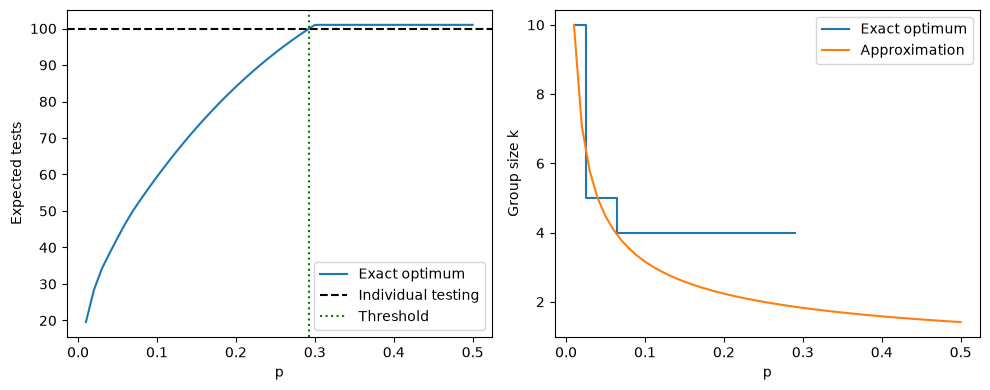

In [6]:
k_values = [k for k in range(1, 101) if n % k == 0]

fine_p = np.arange(0.0001, 0.5, 0.0001)
threshold = max(p for p in fine_p
                if min(expected_tests(n, k, p) for k in k_values) < n)

print("Exact threshold:", round(threshold, 4))
print("Approximate threshold:", 0.25)

pooling_better = np.array(lowest_avg_values) < n

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(p_values, lowest_avg_values, label="Exact optimum")
plt.axhline(n, color="black", linestyle="--", label="Individual testing")
plt.axvline(threshold, color="green", linestyle=":", label="Threshold")
plt.xlabel("p")
plt.ylabel("Expected tests")
plt.legend()

plt.subplot(1, 2, 2)
plt.step(p_values[pooling_better],
         np.array(ideal_k_values)[pooling_better],
         where="mid", label="Exact optimum")
plt.plot(p_values, 1 / np.sqrt(p_values), label="Approximation")
plt.xlabel("p")
plt.ylabel("Group size k")
plt.legend()

plt.tight_layout()
plt.show()

The curve crosses $\text{Expected number of tests}=100$ at $p\approx0.29$, so pooling is the better strategy for $p\leq0.29$ and individual testing takes over above it.

The small $p$ approximation predicted $p<0.25$. It is therefore a decent approximation, but it slightly underestimates how long pooling stays useful.

The graph on the right gives the same result. The approximation $\sqrt{\frac{1}{p}}$ follows the ideal $k$ well for small $p$ but drifts away as $p$ grows. The optimal $k$ changes in discrete steps as it can only take divisors of 100. The line stops at p=0.29, as after that no $k$ is still ideal.